## Neutrino flux evolution with atmospheric height

This notebook demonstrates how the atmospheric neutrino flux builds up as a function of altitude.
It requires a spline file generated with a height grid (see `daemonflux-spline-generator` with a height-grid config).

The key idea: cosmic rays interact high in the atmosphere and produce mesons. As these mesons propagate downward they decay into neutrinos and muons. By evaluating the flux at different altitudes we can see how the flux accumulates along the atmospheric column.

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from daemonflux import Flux
import pathlib

rcParams["figure.dpi"] = 125

### Load a spline file with height grid

The spline file must have been generated with a height grid configuration (e.g. `conf_icecube_hgrid.py`).
Adjust `spl_file` to point to your height-grid spline file.

In [4]:
# Point to the height-grid spline file
spl_file = pathlib.Path(
    "../../daemonflux-spline-generator/resources/daemonsplines_icecube_hgrid.pkl"
)
assert spl_file.is_file(), f"Spline file not found: {spl_file}"

fl = Flux(spl_file=str(spl_file), use_calibration=True, debug=1)
print("Supported fluxes:", fl.supported_fluxes)

Supported fluxes: ['IceCube']


In [5]:
# Inspect the height grid
entry = fl._get_flux_instance("IceCube")
height_grid = entry.height_grid
print(
    f"Height grid: {height_grid[0]:.1f} – {height_grid[-1]:.1f} km "
    f"in {len(height_grid)} steps of {np.diff(height_grid)[0]:.1f} km"
)
print(f"Available quantities: {fl.quantities}")

Height grid: 0.0 – 60.0 km in 121 steps of 0.5 km
Available quantities: ['muflux', 'muratio', 'numuflux', 'numuratio', 'nueflux', 'nueratio', 'flavorratio', 'mu+', 'mu-', 'numu', 'antinumu', 'nue', 'antinue', 'total_muflux', 'total_muratio', 'total_numuflux', 'total_numuratio', 'total_nueflux', 'total_nueratio', 'total_flavorratio', 'total_mu+', 'total_mu-', 'total_numu', 'total_antinumu', 'total_nue', 'total_antinue']


### Flux vs height at a fixed energy and zenith angle

For a vertical ($\theta_z = 0°$) direction, the neutrino flux grows from near-zero at high altitudes to its full value at the surface.
At higher altitudes only neutrinos produced above that level contribute.

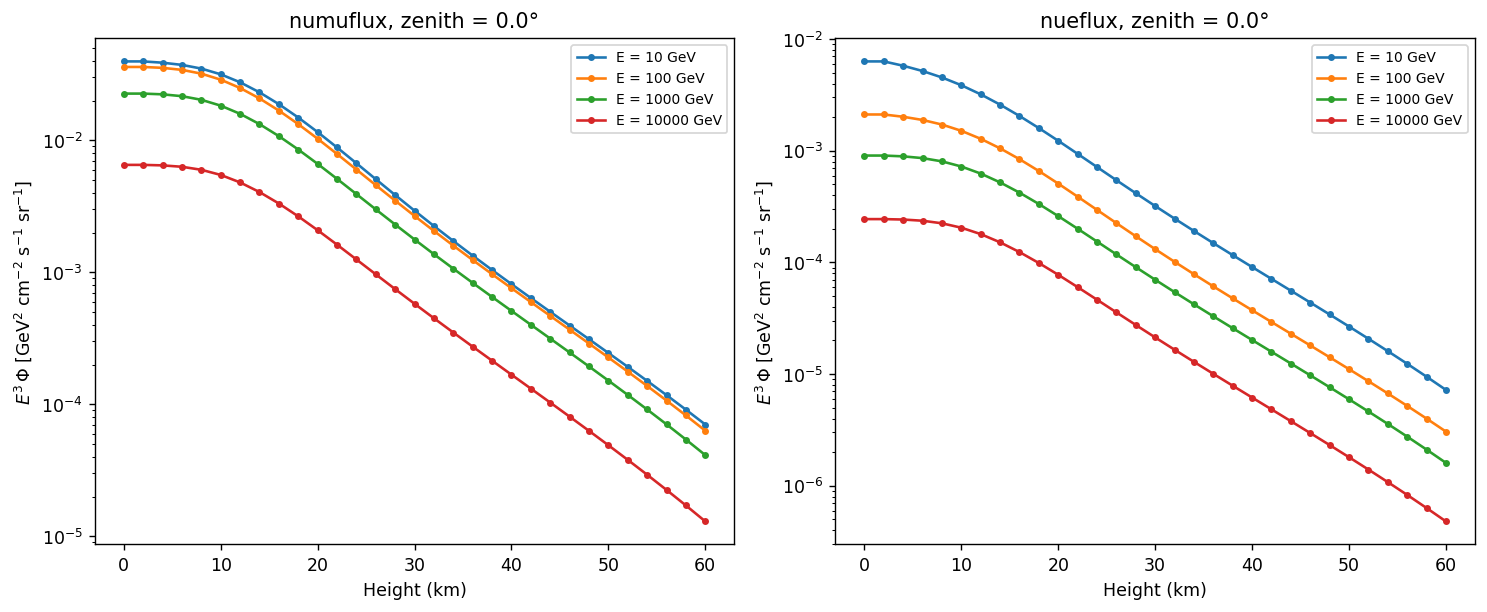

In [6]:
# Select a subset of heights (surface to 60 km)
heights = height_grid[::4]  # every 2 km
energies_check = [10.0, 100.0, 1e3, 1e4]  # GeV
zenith = 0.0  # vertical (downgoing)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for quantity, ax in zip(["numuflux", "nueflux"], axes):
    for E in energies_check:
        flux_vs_h = np.array(
            [fl.flux(np.array([E]), zenith, quantity, height_km=h) for h in heights]
        )
        ax.plot(heights, flux_vs_h, "o-", ms=3, label=f"E = {E:.0f} GeV")

    ax.set_xlabel("Height (km)")
    ax.set_ylabel(r"$E^3\,\Phi$ [GeV$^2$ cm$^{-2}$ s$^{-1}$ sr$^{-1}$]")
    ax.set_title(f"{quantity}, zenith = {zenith}°")
    ax.legend(fontsize=8)
    ax.set_yscale("log")

plt.tight_layout()

### Flux spectra at different altitudes

Comparing the energy spectrum at the surface, 10 km, 20 km, and 40 km shows how the spectrum progressively fills in as particles traverse more atmosphere.

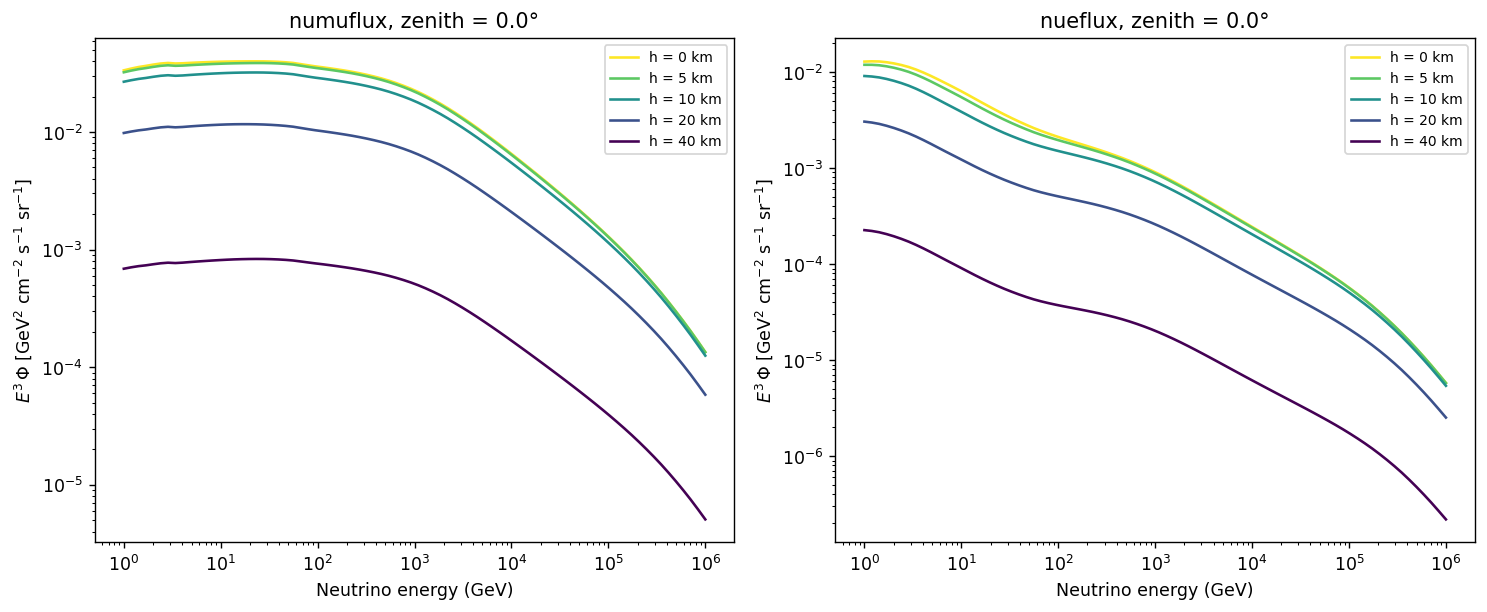

In [7]:
egrid = np.logspace(0, 6, 80)
zenith = 0.0
selected_heights = [0.0, 5.0, 10.0, 20.0, 40.0]
cmap = plt.cm.viridis_r

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for quantity, ax in zip(["numuflux", "nueflux"], axes):
    for i, h in enumerate(selected_heights):
        color = cmap(i / (len(selected_heights) - 1))
        flx = fl.flux(egrid, zenith, quantity, height_km=h)
        ax.loglog(egrid, flx, color=color, label=f"h = {h:.0f} km")

    ax.set_xlabel("Neutrino energy (GeV)")
    ax.set_ylabel(r"$E^3\,\Phi$ [GeV$^2$ cm$^{-2}$ s$^{-1}$ sr$^{-1}$]")
    ax.set_title(f"{quantity}, zenith = {zenith}°")
    ax.legend(fontsize=8)

plt.tight_layout()

### 2D view: flux as a function of energy and height

A color map showing the flux intensity across the (energy, height) plane provides a complete picture of where in the atmosphere each energy range is produced.

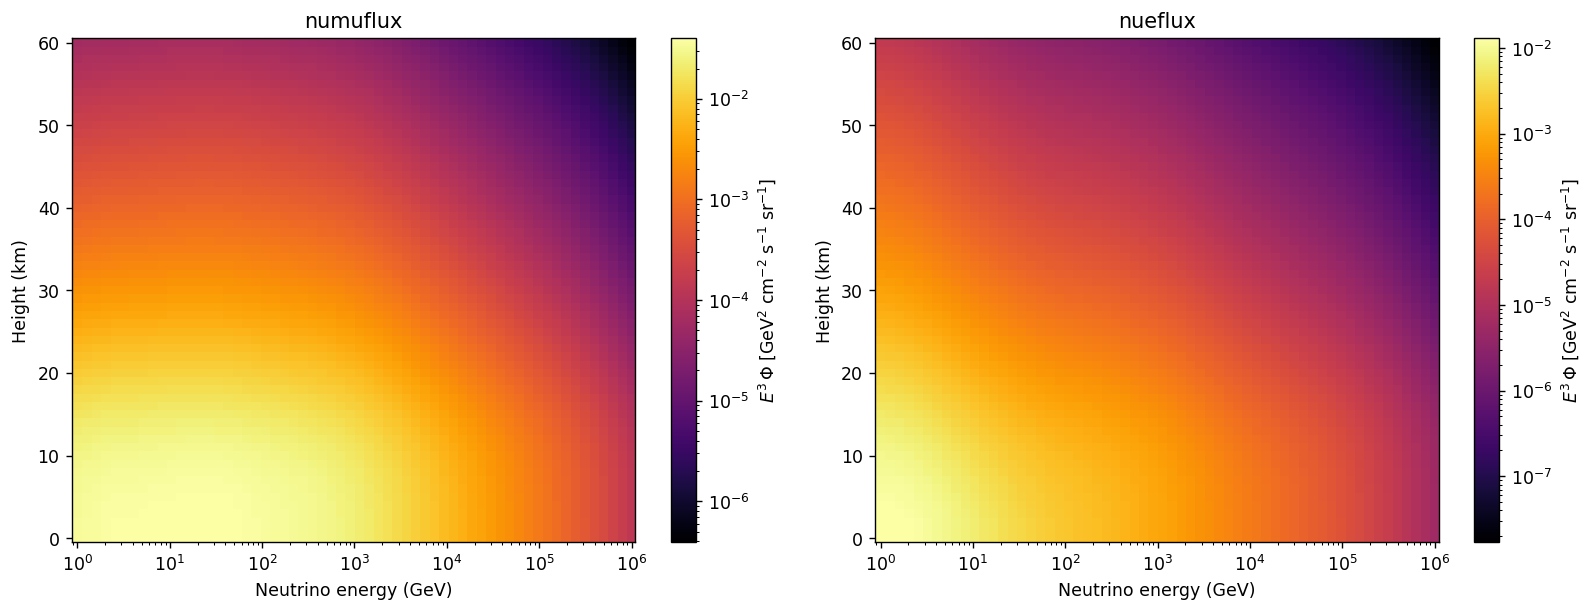

In [8]:
egrid_2d = np.logspace(0, 6, 60)
heights_2d = height_grid[::2]  # every 1 km
zenith = 0.0

flux_map = {}
for quantity in ["numuflux", "nueflux"]:
    grid = np.zeros((len(heights_2d), len(egrid_2d)))
    for ih, h in enumerate(heights_2d):
        grid[ih, :] = fl.flux(egrid_2d, zenith, quantity, height_km=h)
    flux_map[quantity] = grid

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for quantity, ax in zip(["numuflux", "nueflux"], axes):
    pcm = ax.pcolormesh(
        egrid_2d,
        heights_2d,
        flux_map[quantity],
        shading="nearest",
        norm=plt.matplotlib.colors.LogNorm(),
        cmap="inferno",
    )
    ax.set_xscale("log")
    ax.set_xlabel("Neutrino energy (GeV)")
    ax.set_ylabel("Height (km)")
    ax.set_title(quantity)
    fig.colorbar(pcm, ax=ax, label=r"$E^3\,\Phi$ [GeV$^2$ cm$^{-2}$ s$^{-1}$ sr$^{-1}$]")

plt.tight_layout()

### Ratio to surface flux

Normalizing the flux at each altitude by the surface value highlights the fraction of the total flux already accumulated at a given height.

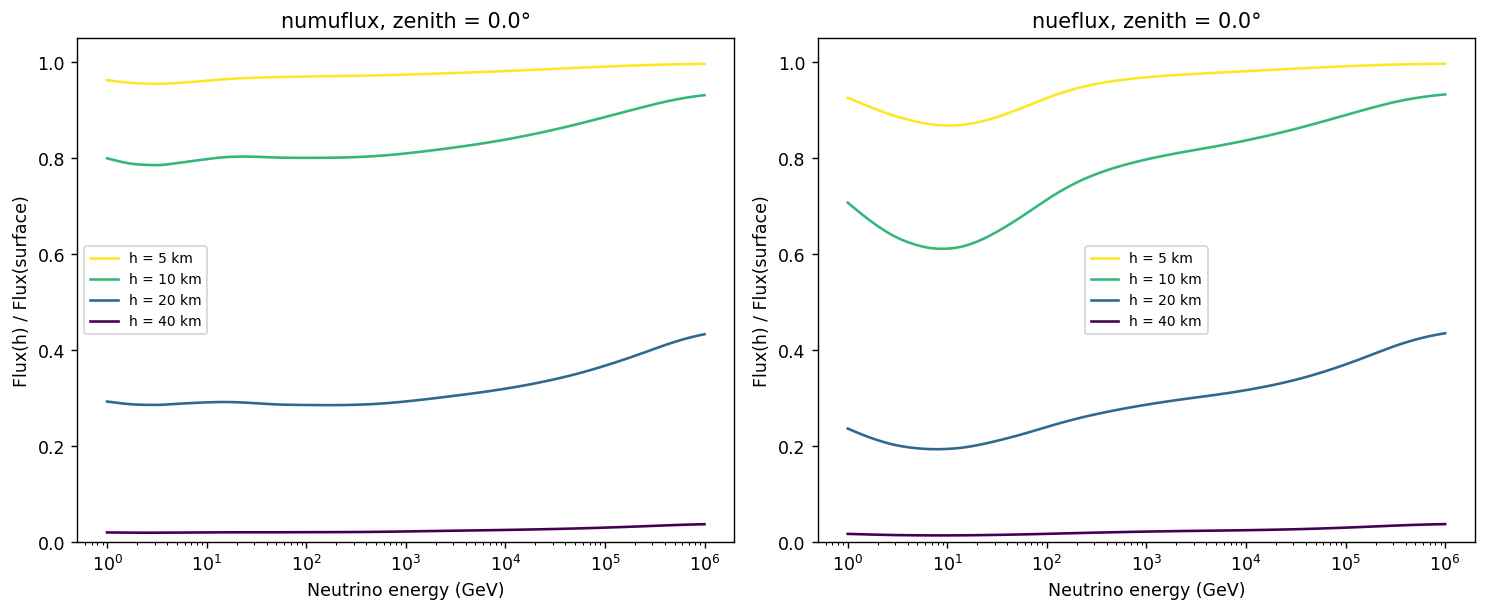

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
zenith = 0.0

for quantity, ax in zip(["numuflux", "nueflux"], axes):
    surface_flux = fl.flux(egrid, zenith, quantity, height_km=0.0)
    for i, h in enumerate(selected_heights[1:]):
        color = cmap(i / (len(selected_heights) - 2))
        ratio = fl.flux(egrid, zenith, quantity, height_km=h) / surface_flux
        ax.semilogx(egrid, ratio, color=color, label=f"h = {h:.0f} km")

    ax.set_xlabel("Neutrino energy (GeV)")
    ax.set_ylabel("Flux(h) / Flux(surface)")
    ax.set_title(f"{quantity}, zenith = {zenith}°")
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1.05)

plt.tight_layout()

### Height profile at different zenith angles

For inclined directions particles travel a longer slant path through the atmosphere.
This changes the production height profile because the effective column density at each altitude is different.

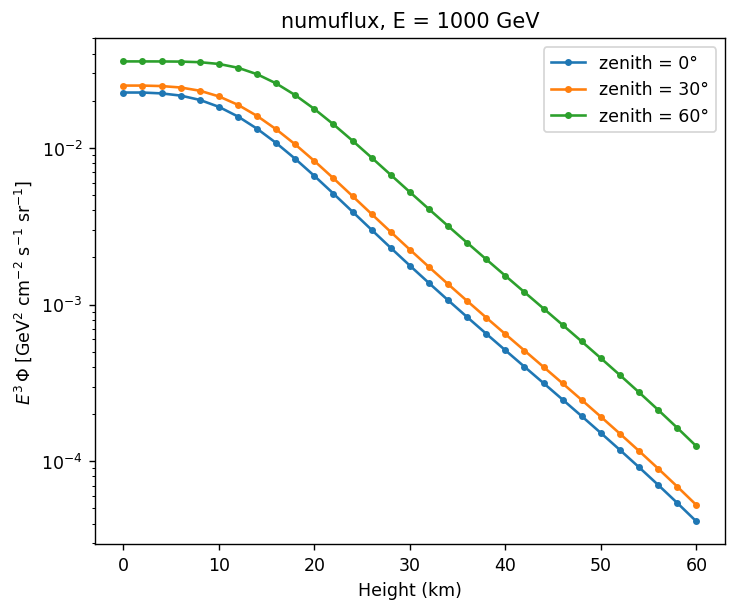

In [10]:
E_fixed = 1e3  # GeV
quantity = "numuflux"
zeniths = [0.0, 30.0, 60.0]

fig, ax = plt.subplots(figsize=(6, 5))

for zen in zeniths:
    flux_vs_h = np.array(
        [fl.flux(np.array([E_fixed]), zen, quantity, height_km=h) for h in heights]
    )
    ax.plot(heights, flux_vs_h, "o-", ms=3, label=f"zenith = {zen:.0f}°")

ax.set_xlabel("Height (km)")
ax.set_ylabel(r"$E^3\,\Phi$ [GeV$^2$ cm$^{-2}$ s$^{-1}$ sr$^{-1}$]")
ax.set_title(f"{quantity}, E = {E_fixed:.0f} GeV")
ax.set_yscale("log")
ax.legend()
plt.tight_layout()

### Error bands at different heights

The uncertainty on the flux can also be evaluated at arbitrary heights.

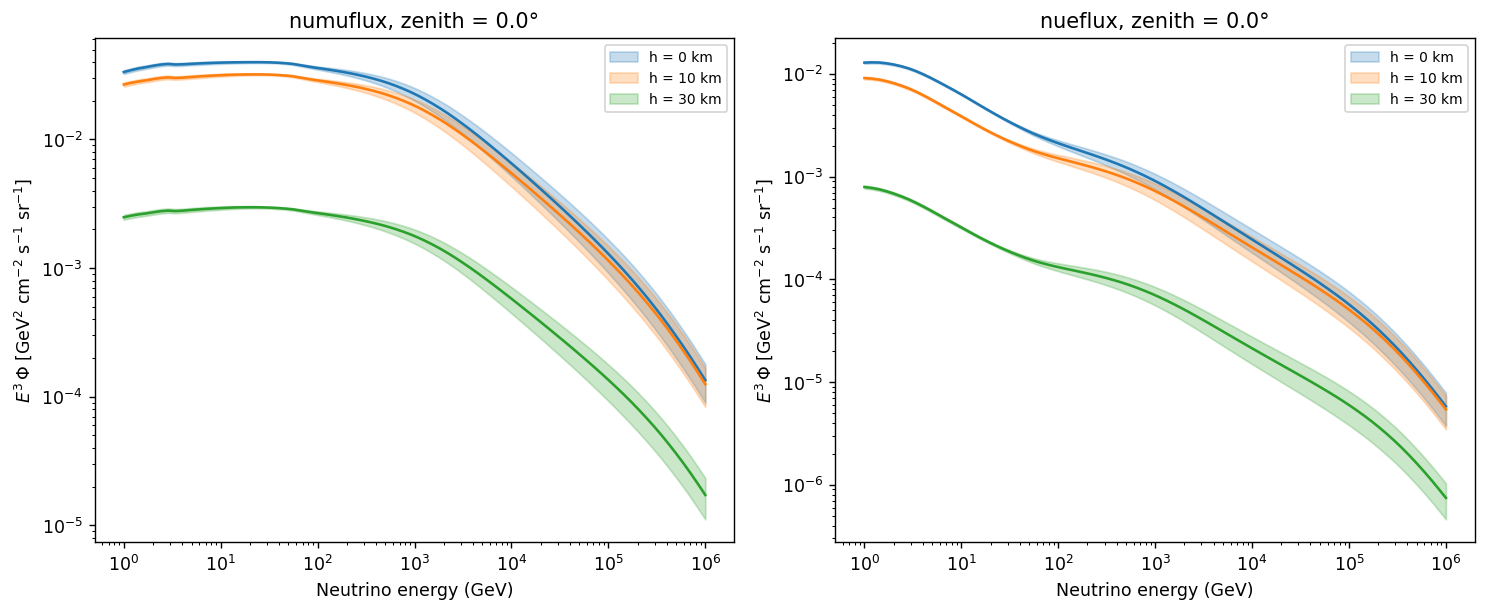

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
zenith = 0.0
heights_err = [0.0, 10.0, 30.0]
colors = ["C0", "C1", "C2"]

for quantity, ax in zip(["numuflux", "nueflux"], axes):
    for h, c in zip(heights_err, colors):
        flx = fl.flux(egrid, zenith, quantity, height_km=h)
        err = fl.error(egrid, zenith, quantity, height_km=h)
        ax.loglog(egrid, flx, color=c)
        ax.fill_between(
            egrid, flx - err, flx + err, alpha=0.25, color=c, label=f"h = {h:.0f} km"
        )

    ax.set_xlabel("Neutrino energy (GeV)")
    ax.set_ylabel(r"$E^3\,\Phi$ [GeV$^2$ cm$^{-2}$ s$^{-1}$ sr$^{-1}$]")
    ax.set_title(f"{quantity}, zenith = {zenith}°")
    ax.legend(fontsize=8)

plt.tight_layout()

### Relative uncertainty vs height

Does the relative uncertainty change with altitude?

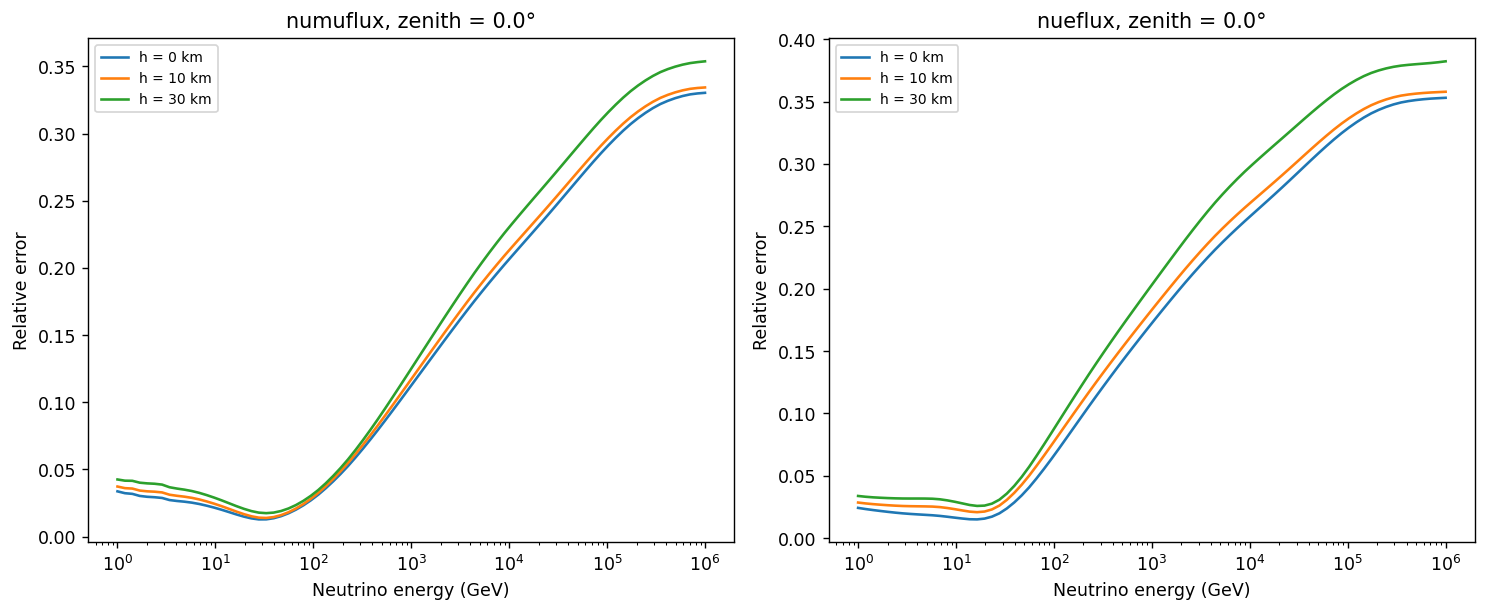

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
zenith = 0.0

for quantity, ax in zip(["numuflux", "nueflux"], axes):
    for h, c in zip(heights_err, colors):
        flx = fl.flux(egrid, zenith, quantity, height_km=h)
        err = fl.error(egrid, zenith, quantity, height_km=h)
        ax.semilogx(egrid, err / flx, color=c, label=f"h = {h:.0f} km")

    ax.set_xlabel("Neutrino energy (GeV)")
    ax.set_ylabel("Relative error")
    ax.set_title(f"{quantity}, zenith = {zenith}°")
    ax.legend(fontsize=8)

plt.tight_layout()

### Muon flux height evolution

The muon flux can also be studied as a function of height. Unlike neutrinos, muons lose energy as they propagate downward, so the high-energy tail is suppressed at lower altitudes relative to higher ones.

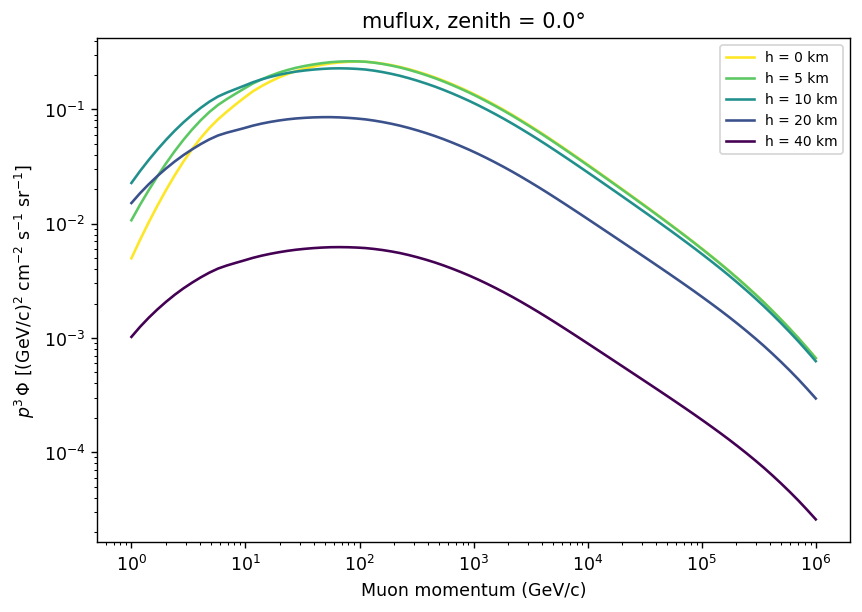

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
zenith = 0.0

for i, h in enumerate(selected_heights):
    color = cmap(i / (len(selected_heights) - 1))
    flx = fl.flux(egrid, zenith, "muflux", height_km=h)
    ax.loglog(egrid, flx, color=color, label=f"h = {h:.0f} km")

ax.set_xlabel("Muon momentum (GeV/c)")
ax.set_ylabel(r"$p^3\,\Phi$ [(GeV/c)$^2$ cm$^{-2}$ s$^{-1}$ sr$^{-1}$]")
ax.set_title(f"muflux, zenith = {zenith}°")
ax.legend(fontsize=8)
plt.tight_layout()